# Código mínimo para AdaBoost

In [5]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()


X = data.data
y = data.target

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state =42)

In [8]:
from sklearn.ensemble import AdaBoostClassifier

model_adaboost = AdaBoostClassifier(n_estimators= 100, random_state = 42)

model_adaboost_train = model_adaboost.fit(X_train, y_train)

In [10]:
from sklearn.metrics import accuracy_score

predict_adaboost_train = model_adaboost.predict(X_train)

accuracy_score_adaboost_train = accuracy_score(y_train, predict_adaboost_train)

print(f"El accuracy para el modelo con los datos de entrenamiento es", accuracy_score_adaboost_train)

El accuracy para el modelo con los datos de entrenamiento es 1.0


In [11]:
predict_adaboost_test = model_adaboost.predict(X_test)

accuracy_score_adaboost_test = accuracy_score(y_test, predict_adaboost_test)

print(f"El accuracy para el modelo con los datos de entrenamiento es", accuracy_score_adaboost_test)

El accuracy para el modelo con los datos de entrenamiento es 0.9736842105263158


Nótese como en este caso el modelo mejora en test respecto al árbol y el random forest. Esta técnica de ensamblado, concretamente de boosting, entrena modelos de manera secuencial. Cada modelo aprende de los errores del modelo anterior. Este modelo, llamado AdaBoost es bastante simple. Se trata (100 en este caso) de stumps, que son modelos de un nivel (árboles de una pregunta) que de manera secuencial intentan mejorar las observaciones clasificadas  erróneas del modelo anterior. Las erróneas van pesando más, mientras que las observaciones correctas van pesando menos. Esto permite que el siguiente modelo se fije más en las observaciones que se predijeron de manera errónea y trate de mejorarlas. A su vez en la votación final en base a lo bueno que haya sido un modelo su aportación importa más o menos. Stumps debido a que nos interesa tener algo que mejorar. A pesar de que el modelo base sea el mismo, árboles de un nivel, debido a lo que reciben del modelo anterior sus errores, su aprendizaje es completamente diferente. 

Además, este modelo reduce el sesgo, una fuente de error de los modelos que produce underfitting. Debido a que cada vez va mejorando y aprendiendo patrones más complejos, el modelo se vuelva más potente.

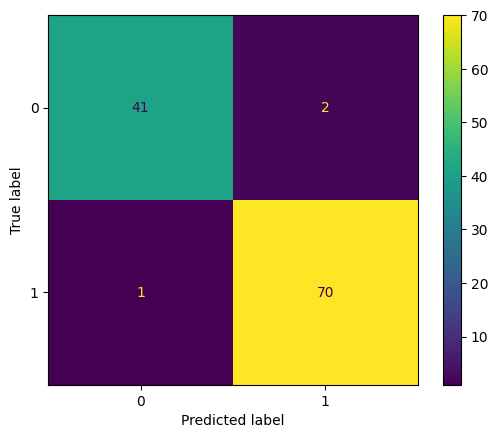

In [15]:
# matriz de confusión de un modelo
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

matrix_test = confusion_matrix(y_test, predict_adaboost_test)

ConfusionMatrixDisplay(matrix_test).plot()

Nótese que tengo un Falso Negativo, me preocupa más, ya que estoy diciendo que algo es benigno cuando realmente es maligno. Esto hace referencia al recall, en cambio la precisión me da un poco más igual. No me importa tanto predecir maligno cuando es benigno. Las consecuencias son menores. El siguiente objetivo será que no se me escape ningún "malo", es decir, aumentar el recall (reducir el umbral de decisión), aunque eso suponga tener una menor precisión: predeciré malignos que no lo son.

In [27]:
predict_adaboost_test_v2_prob = model_adaboost.predict_proba(X_test)

In [41]:
import numpy as np 

predict_adaboost_test_v2 = np.where(predict_adaboost_test_v2_prob[:, 1] < 0.45, 0, 1) 

predict_adaboost_test_v2_prob[:, 1], predict_adaboost_test_v2

(array([0.55383155, 0.27626223, 0.32032465, 0.66783713, 0.78800874,
        0.25923236, 0.27636486, 0.45542865, 0.45032477, 0.68714146,
        0.53968898, 0.36235073, 0.64020435, 0.37614771, 0.68411885,
        0.32806704, 0.64937716, 0.75826168, 0.73200485, 0.31028841,
        0.59540262, 0.61661328, 0.25269818, 0.62601093, 0.64476403,
        0.68661571, 0.69365637, 0.6433005 , 0.65418371, 0.27025681,
        0.6791791 , 0.70806403, 0.68589102, 0.68391808, 0.70605103,
        0.61869516, 0.44275793, 0.67914134, 0.28603007, 0.6079551 ,
        0.72566171, 0.3082608 , 0.69619773, 0.69765374, 0.6227927 ,
        0.59096973, 0.68656542, 0.62638373, 0.56856061, 0.73235128,
        0.24710103, 0.24393024, 0.53888508, 0.65140222, 0.77359654,
        0.6230895 , 0.73891089, 0.28896847, 0.45400663, 0.72632453,
        0.65317854, 0.26615255, 0.26548734, 0.60812184, 0.69953062,
        0.6146145 , 0.24800108, 0.26704594, 0.62565456, 0.59894401,
        0.32514315, 0.30956692, 0.66561897, 0.34

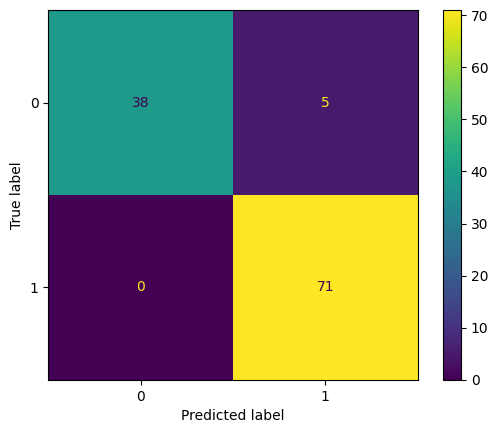

In [42]:
matrix_test_v2 = confusion_matrix(y_test, predict_adaboost_test_v2)

ConfusionMatrixDisplay(matrix_test_v2).plot()

No se nos escapa ningun "malo" jugando con el umbral de decisión-> bajo el umbral, aumenta el recall, reduzco los FN, soy menos conservador al predecir que si-> disminuye precisión. Eso si, mi precisión es peor: predigo que es maligno en casos que es benigno. Nunca digo que es benigno cuando no lo es.